In [24]:
import pandas as pd

teku = pd.read_csv("../data/raw/teku.csv")
mid_b = pd.read_csv("../data/raw/mid_baneshwor.csv")

print("Teku:", teku.shape, teku["datetime_utc"].min(), teku["datetime_utc"].max())
print("Mid Baneshwor:", mid_b.shape, mid_b["datetime_utc"].min(), mid_b["datetime_utc"].max())


Teku: (4343, 6) 2025-11-24T23:15:00Z 2026-09-03T22:15:00Z
Mid Baneshwor: (3871, 6) 2025-11-25T08:15:00Z 2026-09-03T22:15:00Z


In [25]:
print(teku.isna().sum())
print(mid_b.isna().sum())

datetime_utc        0
pm1                 0
pm25                0
relativehumidity    0
temperature         0
um003               0
dtype: int64
datetime_utc        0
pm1                 0
pm25                0
relativehumidity    0
temperature         0
um003               0
dtype: int64


In [26]:
expected_hours = 24 * (pd.to_datetime("2026-09-04") - pd.to_datetime("2025-11-25")).days
print(f"Teku completeness: {len(teku)/expected_hours:.1%}")
print(f"Mid Baneshwor completeness: {len(mid_b)/expected_hours:.1%}")

Teku completeness: 63.9%
Mid Baneshwor completeness: 57.0%


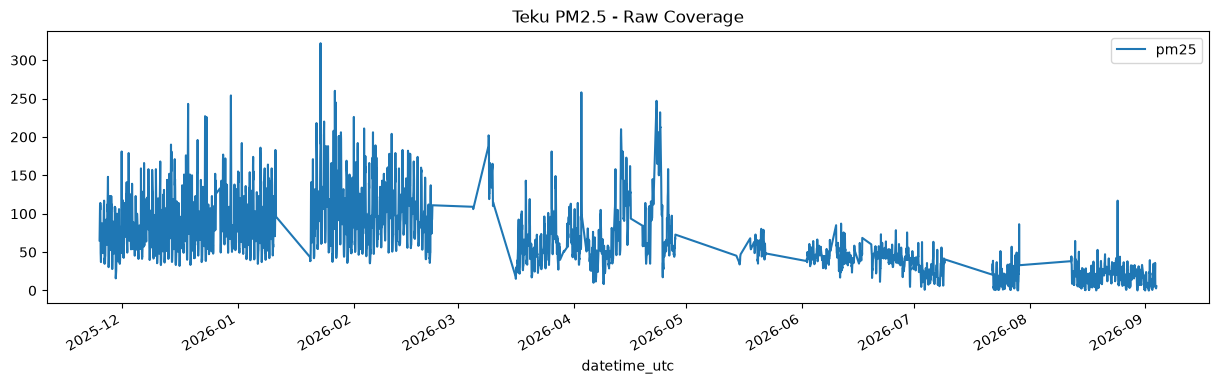

In [27]:
import matplotlib.pyplot as plt
teku["datetime_utc"] = pd.to_datetime(teku["datetime_utc"])
teku.plot(x="datetime_utc", y="pm25", figsize=(15, 4), title="Teku PM2.5 - Raw Coverage")
plt.show()

<Axes: title={'center': 'Teku PM2.5 - true gaps visible'}>

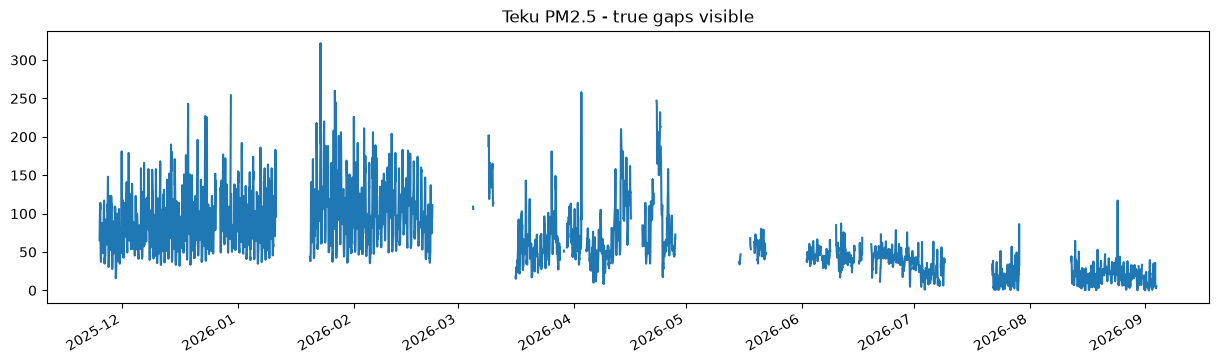

In [28]:
full_range = pd.date_range(start=teku["datetime_utc"].min(), end=teku["datetime_utc"].max(), freq="h")
teku_reindexed = teku.set_index("datetime_utc").reindex(full_range)
teku_reindexed["pm25"].plot(figsize=(15,4), title="Teku PM2.5 - true gaps visible")

In [29]:
is_missing = teku_reindexed["pm25"].isna()
gap_groups = (is_missing != is_missing.shift()).cumsum()
gap_lengths = teku_reindexed[is_missing].groupby(gap_groups).size()
print(gap_lengths.describe())
print(gap_lengths.sort_values(ascending=False).head(10))

count     40.000000
mean      61.225000
std      105.894841
min        1.000000
25%        1.000000
50%       13.000000
75%       58.000000
max      391.000000
dtype: float64
pm25
40    391
68    333
66    306
22    260
48    260
18    217
26    143
24     97
34     73
44     61
dtype: int64


In [30]:
gap_start_times = teku_reindexed[is_missing].groupby(gap_groups).apply(lambda x: x.index[0])
gaps_per_month = gap_start_times.dt.to_period("M").value_counts().sort_index()
print(gaps_per_month)

2025-12    7
2026-01    2
2026-02    2
2026-03    4
2026-04    5
2026-05    4
2026-06    7
2026-07    3
2026-08    6
Freq: M, Name: count, dtype: int64


C:\Users\dipes\AppData\Local\Temp\ipykernel_716\3235088878.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  gaps_per_month = gap_start_times.dt.to_period("M").value_counts().sort_index()


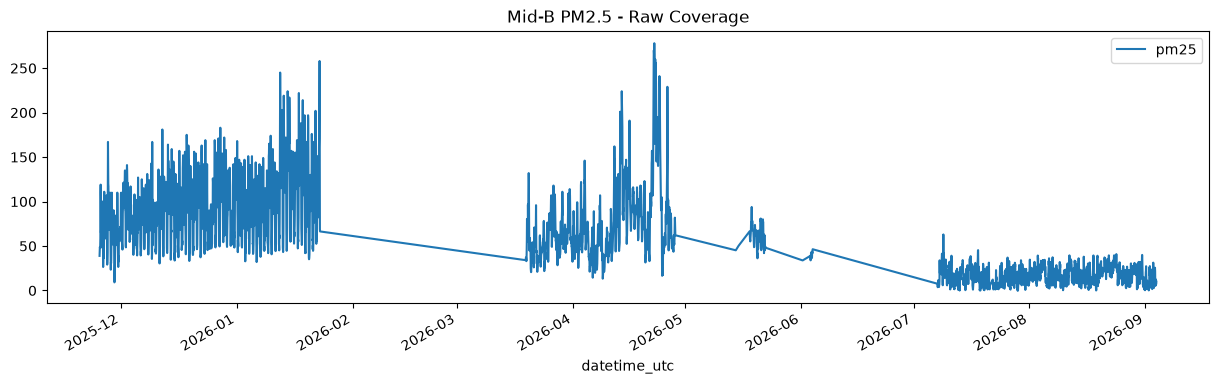

In [31]:
import matplotlib.pyplot as plt
mid_b["datetime_utc"] = pd.to_datetime(mid_b["datetime_utc"])
mid_b.plot(x="datetime_utc", y="pm25", figsize=(15, 4), title="Mid-B PM2.5 - Raw Coverage")
plt.show()

<Axes: title={'center': 'Mid-B PM2.5 - true gaps visible'}>

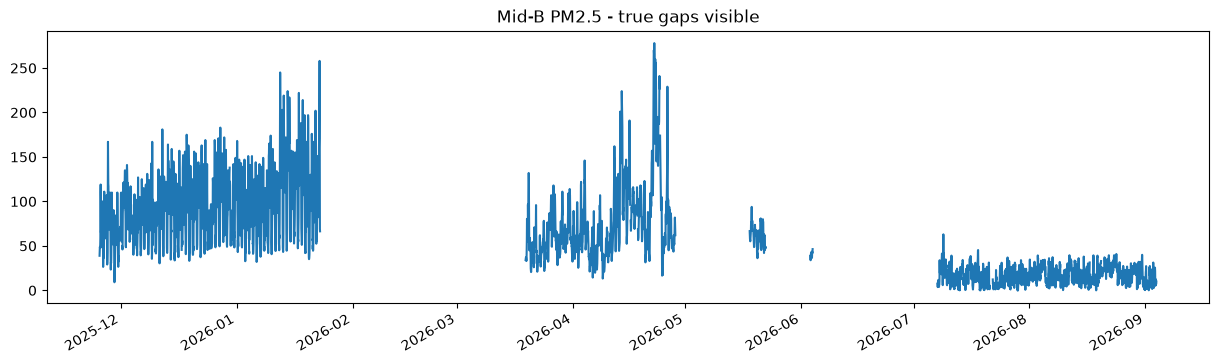

In [32]:
full_range = pd.date_range(start=mid_b["datetime_utc"].min(), end=mid_b["datetime_utc"].max(), freq="h")
mid_b_reindexed = mid_b.set_index("datetime_utc").reindex(full_range)
mid_b_reindexed["pm25"].plot(figsize=(15,4), title="Mid-B PM2.5 - true gaps visible")

In [33]:
is_missing = mid_b_reindexed["pm25"].isna()
gap_groups = (is_missing != is_missing.shift()).cumsum()
gap_lengths = mid_b_reindexed[is_missing].groupby(gap_groups).size()
print(gap_lengths.describe())
print(gap_lengths.sort_values(ascending=False).head(10))

count      20.000000
mean      145.600000
std       337.710776
min         1.000000
25%         1.000000
50%         2.500000
75%        53.500000
max      1318.000000
dtype: float64
pm25
12    1318
32     800
20     387
28     237
24      70
30      48
36      18
22      17
26       3
38       3
dtype: int64


In [34]:
gap_start_times = mid_b_reindexed[is_missing].groupby(gap_groups).apply(lambda x: x.index[0])
gaps_per_month = gap_start_times.dt.to_period("M").value_counts().sort_index()
print(gaps_per_month)

2025-12    4
2026-01    2
2026-04    4
2026-05    4
2026-06    2
2026-07    2
2026-08    2
Freq: M, Name: count, dtype: int64


C:\Users\dipes\AppData\Local\Temp\ipykernel_716\1873462191.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  gaps_per_month = gap_start_times.dt.to_period("M").value_counts().sort_index()
